<a href="https://colab.research.google.com/github/Roshanraj2580/Rice_Leaf_Detection/blob/main/Resnet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_curve,
    auc,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize


In [18]:
import os

print("Train exists:", os.path.exists("/content/drive/MyDrive/Minor_Project/Data/Splitted_Strict/train"))
print("Val exists  :", os.path.exists("/content/drive/MyDrive/Minor_Project/Data/Splitted_Strict/val"))
print("Test exists :", os.path.exists("/content/drive/MyDrive/Minor_Project/Data/Splitted_Strict/test"))


Train exists: True
Val exists  : True
Test exists : True


In [19]:
import os

# Dataset paths
train_dir = "/content/drive/MyDrive/Minor_Project/Data/Splitted_Strict/train"
val_dir = "/content/drive/MyDrive/Minor_Project/Data/Splitted_Strict/val"
test_dir = "/content/drive/MyDrive/Minor_Project/Data/Splitted_Strict/test"

# Model save directory
model_dir = "/content/drive/MyDrive/Minor_Project/Models/ResNet 50"
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, "resnet50_rice_leaf_model.keras")

# Results save directory
results_dir = os.path.join(model_dir, "results")
os.makedirs(results_dir, exist_ok=True)

# Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.0001

print("Paths and parameters loaded.")


Paths and parameters loaded.


In [20]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)

print("Classes:", class_names)


Found 1739 images belonging to 4 classes.
Found 367 images belonging to 4 classes.
Found 340 images belonging to 4 classes.
Classes: ['Bacterialblight', 'Blast', 'Brownspot', 'Tungro']


In [21]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

for layer in base_model.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [22]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=model_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    )
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)

print("Model saved at:", model_path)


Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 544ms/step - accuracy: 0.5214 - loss: 1.3018
Epoch 1: val_accuracy improved from None to 0.91281, saving model to /content/drive/MyDrive/Minor_Project/Models/ResNet 50/resnet50_rice_leaf_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Minor_Project/Models/ResNet 50/resnet50_rice_leaf_model.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 52s 734ms/step - accuracy: 0.6492 - loss: 0.9197 - val_accuracy: 0.9128 - val_loss: 0.3439
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 515ms/step - accuracy: 0.8258 - loss: 0.4442
Epoch 2: val_accuracy improved from 0.91281 to 0.94550, saving model to /content/drive/MyDrive/Minor_Project/Models/ResNet 50/resnet50_rice_leaf_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Minor_Project/Models/ResNet 50/resnet50_rice_leaf_model.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 69s 567ms/step - accuracy: 0.8488 - loss: 0.4021 - val_accuracy: 0.9455 - val_loss: 0.1910
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [23]:
import os

base = "/content/drive/MyDrive/Minor_Project/Data/Splitted_Strict"

for split in ["train", "val", "test"]:
    print(f"\n{split.upper()}")
    split_path = os.path.join(base, split)
    for cls in sorted(os.listdir(split_path)):
        cls_path = os.path.join(split_path, cls)
        if os.path.isdir(cls_path):
            count = len(os.listdir(cls_path))
            print(f"{cls}: {count}")



TRAIN
Bacterialblight: 305
Blast: 323
Brownspot: 606
Tungro: 505

VAL
Bacterialblight: 206
Blast: 1
Brownspot: 4
Tungro: 156

TEST
Bacterialblight: 4
Blast: 160
Brownspot: 4
Tungro: 172


In [24]:
best_model = load_model(model_path)
print("Loaded model from:", model_path)


Loaded model from: /content/drive/MyDrive/Minor_Project/Models/ResNet 50/resnet50_rice_leaf_model.keras


In [25]:
train_loss, train_acc = best_model.evaluate(train_generator, verbose=1)
val_loss, val_acc = best_model.evaluate(val_generator, verbose=1)
test_loss, test_acc = best_model.evaluate(test_generator, verbose=1)

print("\nCore Metrics")
print(f"Train Accuracy      : {train_acc:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Test Accuracy       : {test_acc:.4f}")
print(f"Train Loss          : {train_loss:.4f}")
print(f"Validation Loss     : {val_loss:.4f}")
print(f"Test Loss           : {test_loss:.4f}")


55/55 ━━━━━━━━━━━━━━━━━━━━ 36s 529ms/step - accuracy: 0.9770 - loss: 0.0903
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 302ms/step - accuracy: 0.9809 - loss: 0.0748
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 432ms/step - accuracy: 0.8941 - loss: 0.2565

Core Metrics
Train Accuracy      : 0.9770
Validation Accuracy : 0.9809
Test Accuracy       : 0.8941
Train Loss          : 0.0903
Validation Loss     : 0.0748
Test Loss           : 0.2565


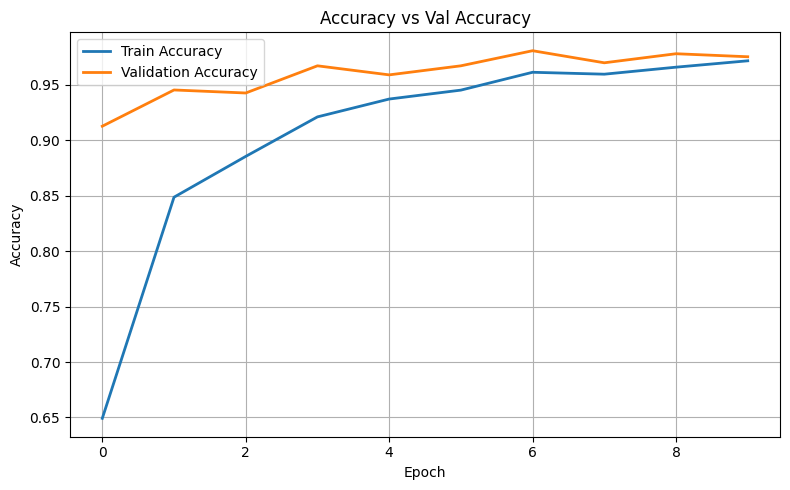

Saved: /content/drive/MyDrive/Minor_Project/Models/ResNet 50/results/accuracy_vs_val_accuracy.png


In [26]:
 plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy", linewidth=2)
plt.plot(history.history["val_accuracy"], label="Validation Accuracy", linewidth=2)
plt.title("Accuracy vs Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

acc_plot_path = os.path.join(results_dir, "accuracy_vs_val_accuracy.png")
plt.savefig(acc_plot_path, dpi=300)
plt.show()

print("Saved:", acc_plot_path)


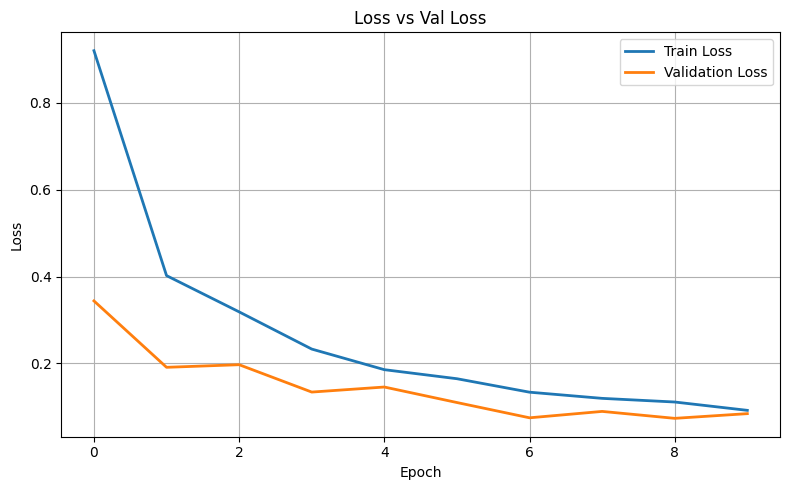

Saved: /content/drive/MyDrive/Minor_Project/Models/ResNet 50/results/loss_vs_val_loss.png


In [27]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss", linewidth=2)
plt.plot(history.history["val_loss"], label="Validation Loss", linewidth=2)
plt.title("Loss vs Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

loss_plot_path = os.path.join(results_dir, "loss_vs_val_loss.png")
plt.savefig(loss_plot_path, dpi=300)
plt.show()

print("Saved:", loss_plot_path)


In [28]:
test_generator.reset()
y_prob = best_model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_generator.classes


11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 530ms/step


In [29]:
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")
acc = accuracy_score(y_true, y_pred)

print("\nClassification Metrics")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"Accuracy  : {acc:.4f}")



Classification Metrics
Precision : 0.9808
Recall    : 0.8941
F1-score  : 0.9241
Accuracy  : 0.8941


In [30]:
report = classification_report(y_true, y_pred, target_names=class_names)
print("\nClassification Report\n")
print(report)

report_path = os.path.join(results_dir, "classification_report.txt")
with open(report_path, "w") as f:
    f.write(report)

print("Saved:", report_path)



Classification Report

                 precision    recall  f1-score   support

Bacterialblight       0.17      1.00      0.29         4
          Blast       1.00      0.78      0.87       160
      Brownspot       0.20      1.00      0.33         4
         Tungro       1.00      1.00      1.00       172

       accuracy                           0.89       340
      macro avg       0.59      0.94      0.62       340
   weighted avg       0.98      0.89      0.92       340

Saved: /content/drive/MyDrive/Minor_Project/Models/ResNet 50/results/classification_report.txt


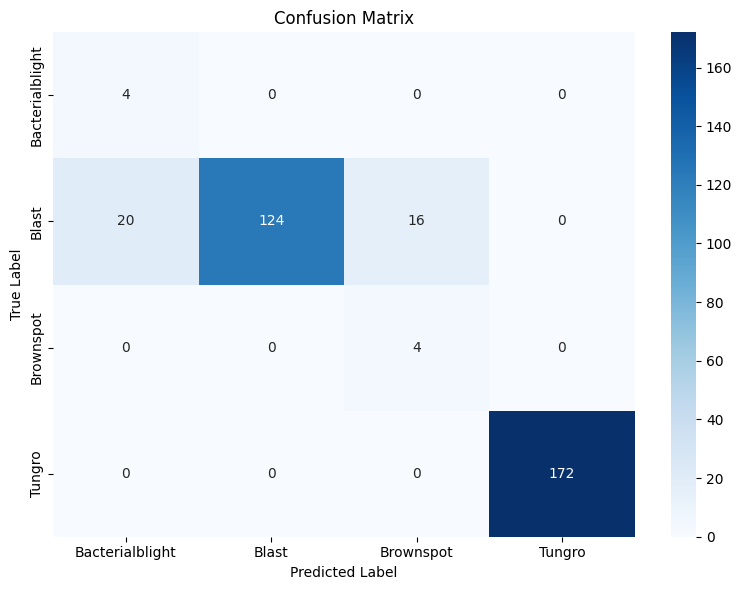

Saved: /content/drive/MyDrive/Minor_Project/Models/ResNet 50/results/confusion_matrix.png


In [31]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

cm_path = os.path.join(results_dir, "confusion_matrix.png")
plt.savefig(cm_path, dpi=300)
plt.show()

print("Saved:", cm_path)


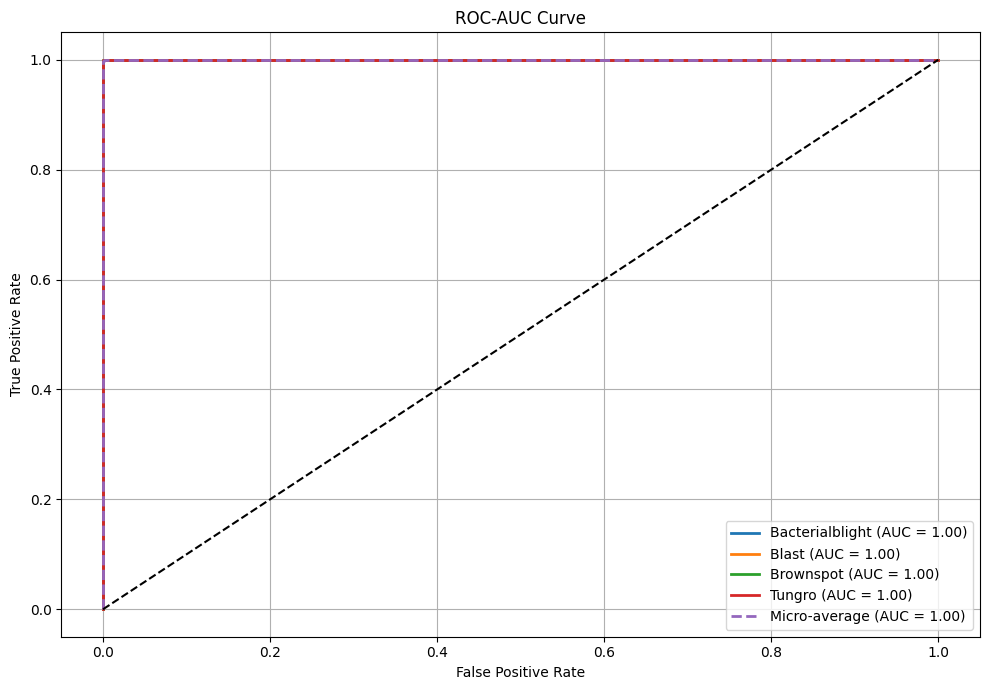

Saved: /content/drive/MyDrive/Minor_Project/Models/ResNet 50/results/roc_auc_curve.png


In [22]:

y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))

fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(10, 7))

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], linewidth=2, label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

plt.plot(fpr_micro, tpr_micro, linestyle="--", linewidth=2, label=f"Micro-average (AUC = {roc_auc_micro:.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC-AUC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()

roc_path = os.path.join(results_dir, "roc_auc_curve.png")
plt.savefig(roc_path, dpi=300)
plt.show()

print("Saved:", roc_path)


In [23]:
roc_auc_macro = roc_auc_score(y_true_bin, y_prob, multi_class="ovr", average="macro")
roc_auc_weighted = roc_auc_score(y_true_bin, y_prob, multi_class="ovr", average="weighted")

print("\nROC-AUC Scores")
print(f"Macro ROC-AUC    : {roc_auc_macro:.4f}")
print(f"Weighted ROC-AUC : {roc_auc_weighted:.4f}")



ROC-AUC Scores
Macro ROC-AUC    : 1.0000
Weighted ROC-AUC : 1.0000


In [26]:
metrics_dict = {
    "train_accuracy": float(train_acc),
    "validation_accuracy": float(val_acc),
    "test_accuracy": float(test_acc),
    "train_loss": float(train_loss),
    "validation_loss": float(val_loss),
    "test_loss": float(test_loss),
    "precision_weighted": float(precision),
    "recall_weighted": float(recall),
    "f1_score_weighted": float(f1),
    "test_accuracy_sklearn": float(acc),
    "roc_auc_macro": float(roc_auc_macro),
    "roc_auc_weighted": float(roc_auc_weighted)
}

metrics_path = os.path.join(results_dir, "metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics_dict, f, indent=4)

print("Saved:", metrics_path)


Saved: /content/drive/MyDrive/Minor_Project/Models/ResNet 50/results/metrics.json


In [27]:
summary_path = os.path.join(results_dir, "final_metrics_summary.txt")

with open(summary_path, "w") as f:
    f.write("Final Evaluation Metrics\n")
    f.write("========================\n\n")
    f.write(f"Train Accuracy      : {train_acc:.4f}\n")
    f.write(f"Validation Accuracy : {val_acc:.4f}\n")
    f.write(f"Test Accuracy       : {test_acc:.4f}\n")
    f.write(f"Train Loss          : {train_loss:.4f}\n")
    f.write(f"Validation Loss     : {val_loss:.4f}\n")
    f.write(f"Test Loss           : {test_loss:.4f}\n")
    f.write(f"Precision           : {precision:.4f}\n")
    f.write(f"Recall              : {recall:.4f}\n")
    f.write(f"F1-score            : {f1:.4f}\n")
    f.write(f"Accuracy            : {acc:.4f}\n")
    f.write(f"Macro ROC-AUC       : {roc_auc_macro:.4f}\n")
    f.write(f"Weighted ROC-AUC    : {roc_auc_weighted:.4f}\n")

print("Saved:", summary_path)
print("\nAll results saved in:", results_dir)


Saved: /content/drive/MyDrive/Minor_Project/Models/ResNet 50/results/final_metrics_summary.txt

All results saved in: /content/drive/MyDrive/Minor_Project/Models/ResNet 50/results


In [37]:
!pip install gradio


In [38]:

import gradio as gr
import numpy as np
import tensorflow as tf
from PIL import Image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input


In [39]:
model_path = "/content/drive/MyDrive/Minor_Project/Models/ResNet 50/resnet50_rice_leaf_model.keras"
model = load_model(model_path)

print("Model loaded successfully.")


Model loaded successfully.


In [40]:
class_names = ['Bacterialblight', 'Blast', 'Brownspot', 'Tungro']


In [41]:
def predict_rice_leaf(img):
    if img is None:
        return "No image uploaded.", {}

    img = img.convert("RGB")
    img = img.resize((224, 224))

    img_array = np.array(img, dtype=np.float32)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    preds = model.predict(img_array)[0]
    predicted_index = np.argmax(preds)
    predicted_class = class_names[predicted_index]
    confidence = float(preds[predicted_index]) * 100

    if confidence >= 90:
        analysis = "High confidence prediction."
    elif confidence >= 70:
        analysis = "Moderate confidence prediction."
    else:
        analysis = "Low confidence prediction. Please verify with more samples."

    result_text = (
        f"Predicted Disease: {predicted_class}\n"
        f"Confidence: {confidence:.2f}%\n"
        f"Analysis: {analysis}"
    )

    prob_dict = {class_names[i]: float(preds[i]) for i in range(len(class_names))}
    return result_text, prob_dict


In [42]:

interface = gr.Interface(
    fn=predict_rice_leaf,
    inputs=gr.Image(type="pil", label="Upload Rice Leaf Image"),
    outputs=[
        gr.Textbox(label="Prediction Result"),
        gr.Label(label="Prediction Confidence")
    ],
    title="Rice Leaf Disease Detector",
    description="Upload a rice leaf image and the model will predict the disease category.",
    theme="default"
)


In [43]:
interface.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bfb18d3457ab4fa1fc.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
